In [3]:
import os

folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt"
files = os.listdir(folder)
files


['IWT0052602202316.wave.ps.gz',
 'HKD1852602202316.wave.ps.gz',
 'HKD1852602202316.EW',
 'AOM0212602202316.EW',
 'HKD1102602202316.rsp.ps.gz',
 'HKD1282602202316.EW',
 'HKD0942602202316.rsp.ps.gz',
 'HKD1822602202316.EW',
 'AOM0262602202316.EW',
 'AOM0212602202316.rsp.ps.gz',
 'IWT0232602202316.NS',
 'HKD1092602202316.rsp.ps.gz',
 'HKD1582602202316.rsp.ps.gz',
 'HKD1622602202316.NS',
 'IWT0242602202316.NS',
 'HKD1302602202316.NS',
 'AOM0242602202316.wave.ps.gz',
 '20260220231600.knt_rsc2000map.ps.gz',
 'HKD1112602202316.rsp.ps.gz',
 'AOM0202602202316.rsp.ps.gz',
 'HKD0952602202316.rsp.ps.gz',
 'HKD0662602202316.rsp.ps.gz',
 'HKD1252602202316.NS',
 'AOM0212602202316.wave.ps.gz',
 'AOM0222602202316.UD',
 'HKD0992602202316.wave.ps.gz',
 'HKD1322602202316.wave.ps.gz',
 'HKD1812602202316.UD',
 'HKD1082602202316.rsp.ps.gz',
 'HKD1592602202316.rsp.ps.gz',
 'AOM0022602202316.EW',
 'HKD1592602202316.EW',
 'HKD0962602202316.wave.ps.gz',
 'IWT0182602202316.EW',
 'AOM0052602202316.EW',
 'HKD095260

In [4]:
import os

folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt"
files = os.listdir(folder)

# Ambil nama dasar stasiun (tanpa komponen)
stations = {}

for f in files:
    if f.endswith((".EW", ".NS", ".UD")):
        base = f[:-3]  # buang .EW / .NS / .UD
        comp = f[-2:]  # ambil EW / NS / UD
        stations.setdefault(base, []).append(comp)

stations


{'HKD1852602202316': ['EW', 'NS', 'UD'],
 'AOM0212602202316': ['EW', 'NS', 'UD'],
 'HKD1282602202316': ['EW', 'NS', 'UD'],
 'HKD1822602202316': ['EW', 'NS', 'UD'],
 'AOM0262602202316': ['EW', 'NS', 'UD'],
 'IWT0232602202316': ['NS', 'EW', 'UD'],
 'HKD1622602202316': ['NS', 'EW', 'UD'],
 'IWT0242602202316': ['NS', 'EW', 'UD'],
 'HKD1302602202316': ['NS', 'EW', 'UD'],
 'HKD1252602202316': ['NS', 'EW', 'UD'],
 'AOM0222602202316': ['UD', 'NS', 'EW'],
 'HKD1812602202316': ['UD', 'NS', 'EW'],
 'AOM0022602202316': ['EW', 'NS', 'UD'],
 'HKD1592602202316': ['EW', 'NS', 'UD'],
 'IWT0182602202316': ['EW', 'NS', 'UD'],
 'AOM0052602202316': ['EW', 'NS', 'UD'],
 'HKD0952602202316': ['UD', 'NS', 'EW'],
 'IWT0092602202316': ['UD', 'NS', 'EW'],
 'AOM0132602202316': ['UD', 'NS', 'EW'],
 'HKD0922602202316': ['UD', 'NS', 'EW'],
 'HKD1132602202316': ['NS', 'EW', 'UD'],
 'IWT0072602202316': ['NS', 'EW', 'UD'],
 'AOM0142602202316': ['UD', 'NS', 'EW'],
 'HKD0962602202316': ['EW', 'NS', 'UD'],
 'AOM01026022023

In [11]:
import numpy as np

def load_knet_component(path):
    values = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            # hanya proses baris yang dimulai angka atau minus
            if line and (line[0].isdigit() or line[0] == "-"):
                parts = line.split()
                # ambil kolom terakhir (amplitudo)
                try:
                    values.append(float(parts[-1]))
                except:
                    pass
    return np.array(values)


In [12]:
folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt"
station = "HKD1852602202316"

ew = load_knet_component(f"{folder}/{station}.EW")
ns = load_knet_component(f"{folder}/{station}.NS")
ud = load_knet_component(f"{folder}/{station}.UD")


In [13]:
ew.shape, ns.shape, ud.shape


((788,), (788,), (788,))

In [14]:
from scipy.signal import resample

ew_r = resample(ew, 300)
ns_r = resample(ns, 300)
ud_r = resample(ud, 300)

X = np.vstack([ew_r, ns_r, ud_r]).T   # shape (300, 3)


In [15]:
E = np.sum(X**2)


In [18]:
import numpy as np
import tensorflow as tf


In [19]:
tflite_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/ac1_cnn_light.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [20]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)


[{'name': 'serving_default_keras_tensor_32:0', 'index': 0, 'shape': array([  1, 300,   3], dtype=int32), 'shape_signature': array([ -1, 300,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 26, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [21]:
X_input = X.reshape(1, 300, 3).astype(np.float32)


In [22]:
interpreter.set_tensor(input_details[0]['index'], X_input)
interpreter.invoke()
y_pred = interpreter.get_tensor(output_details[0]['index'])


In [23]:
print("Prediksi AC-1:", y_pred)


Prediksi AC-1: [[1.]]


In [24]:
# === [1] SETUP FOLDER INPUT & OUTPUT ===
import os

folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt"
out_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1"

os.makedirs(out_dir, exist_ok=True)
print("Output folder:", out_dir)


Output folder: /Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1


In [25]:
# === [2] PARSER FILE K-NET (AMBIL KOLOM TERAKHIR) ===
import numpy as np

def load_knet_component(path):
    values = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line and (line[0].isdigit() or line[0] == "-"):
                parts = line.split()
                try:
                    values.append(float(parts[-1]))  # kolom terakhir = amplitudo
                except:
                    pass
    return np.array(values)


In [26]:
# === [3] DETEKSI STASIUN LENGKAP (EW, NS, UD) ===
files = os.listdir(folder)
stations = {}

for f in files:
    if f.endswith((".EW", ".NS", ".UD")):
        base = f[:-3]
        comp = f[-2:]
        stations.setdefault(base, []).append(comp)

complete_stations = [s for s, comps in stations.items() if set(comps) == {"EW", "NS", "UD"}]

print("Jumlah stasiun lengkap:", len(complete_stations))


Jumlah stasiun lengkap: 93


In [27]:
# === [4] LOAD MODEL TFLITE AC-1 ===
import tensorflow as tf

tflite_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/ac1_cnn_light.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model TFLite loaded.")


Model TFLite loaded.


In [28]:
# === [5] BATCH PROCESSING SEMUA STASIUN ===
from scipy.signal import resample
from tqdm import tqdm

results = []

for station in tqdm(complete_stations, desc="Processing K-NET Stations"):
    ew = load_knet_component(os.path.join(folder, station + ".EW"))
    ns = load_knet_component(os.path.join(folder, station + ".NS"))
    ud = load_knet_component(os.path.join(folder, station + ".UD"))

    # Resample ke 300 sampel
    ew_r = resample(ew, 300)
    ns_r = resample(ns, 300)
    ud_r = resample(ud, 300)

    # Stack menjadi (300, 3)
    X = np.vstack([ew_r, ns_r, ud_r]).T.astype(np.float32)

    # Inference TFLite
    X_input = X.reshape(1, 300, 3)
    interpreter.set_tensor(input_details[0]['index'], X_input)
    interpreter.invoke()
    y_pred = interpreter.get_tensor(output_details[0]['index'])[0][0]

    # Simpan waveform processed
    np.save(os.path.join(out_dir, f"{station}.npy"), X)

    # Simpan hasil prediksi
    results.append((station, y_pred))


Processing K-NET Stations: 100%|██████████| 93/93 [00:00<00:00, 534.50it/s]


In [31]:
# === [6] SIMPAN HASIL AC-1 KE CSV ===
import pandas as pd

df = pd.DataFrame(results, columns=["station", "ac1_pred"])
csv_path = os.path.join(out_dir, "ac1_results.csv")
df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
df.head()


Saved: /Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/ac1_results.csv


,station,ac1_pred
0,HKD1852602202316,1.0
1,AOM0212602202316,1.0
2,HKD1282602202316,1.0
3,HKD1822602202316,1.0
4,AOM0262602202316,1.0


In [33]:
import pandas as pd

csv_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/ac1_results.csv"
df = pd.read_csv(csv_path)

df[df.ac1_pred < 1.0]


,station,ac1_pred


In [34]:
df[df.ac1_pred < 1.0]


,station,ac1_pred


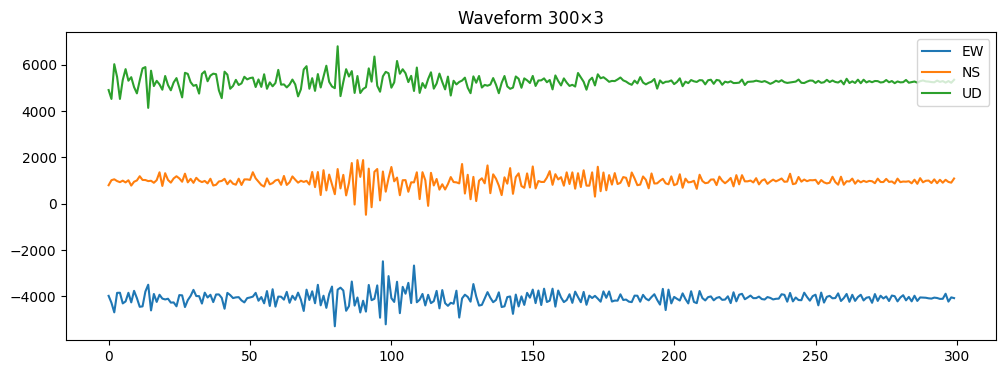

In [35]:
import matplotlib.pyplot as plt
import numpy as np

X = np.load("/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1852602202316.npy")

plt.figure(figsize=(12,4))
plt.plot(X[:,0], label="EW")
plt.plot(X[:,1], label="NS")
plt.plot(X[:,2], label="UD")
plt.legend()
plt.title("Waveform 300×3")
plt.show()


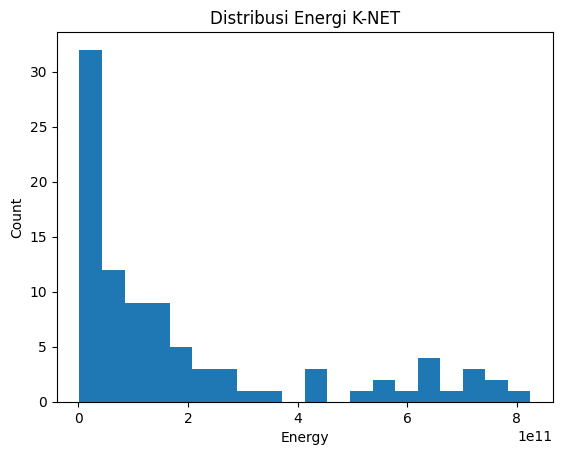

In [36]:
energies = []

for station in df.station:
    X = np.load(f"/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/{station}.npy")
    E = (X**2).sum()
    energies.append(E)

plt.hist(energies, bins=20)
plt.title("Distribusi Energi K-NET")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()


In [37]:
# === [1] SETUP FOLDER INPUT & OUTPUT ===
import os

ac1_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1"
out_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2"

os.makedirs(out_dir, exist_ok=True)
print("Output folder:", out_dir)


Output folder: /Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2


In [38]:
# === [2] MAGNITUDO EVENT ===
Mw_event = 6.4   # isi sesuai metadata event K-NET
print("Magnitudo event:", Mw_event)


Magnitudo event: 6.4


In [41]:
# === [3] LOAD MODEL TFLITE AC-2 ===
import tensorflow as tf

tflite_path_ac2 = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/ac2_quantized.tflite"
interpreter_ac2 = tf.lite.Interpreter(model_path=tflite_path_ac2)
interpreter_ac2.allocate_tensors()

input_details_ac2 = interpreter_ac2.get_input_details()
output_details_ac2 = interpreter_ac2.get_output_details()

print("Model AC-2 TFLite loaded.")


Model AC-2 TFLite loaded.


In [43]:
scale = input_details_ac2[0]['quantization'][0]
zero_point = input_details_ac2[0]['quantization'][1]


In [45]:
# Ambil quantization parameter
scale, zero_point = input_details_ac2[0]['quantization']

# Quantize input
X_q = X_input / scale + zero_point
X_q = np.clip(X_q, -128, 127).astype(np.int8)

# Set tensor INT8
interpreter_ac2.set_tensor(input_details_ac2[0]['index'], X_q)
interpreter_ac2.invoke()

# Output biasanya float32 meskipun input INT8
Mw_pred = interpreter_ac2.get_tensor(output_details_ac2[0]['index'])[0][0]


In [47]:
input_details_ac2[0]['dtype']


numpy.int8

In [48]:
input_details_ac2[0]['quantization']


(0.25998055934906006, 1)

In [50]:
# Ambil quantization parameter
scale, zero_point = input_details_ac2[0]['quantization']

# Quantize input float32 → int8
X_q = X_input / scale + zero_point
X_q = np.clip(X_q, -128, 127).astype(np.int8)

# Set tensor INT8
interpreter_ac2.set_tensor(input_details_ac2[0]['index'], X_q)
interpreter_ac2.invoke()

# Output biasanya float32 meskipun input INT8
Mw_pred = interpreter_ac2.get_tensor(output_details_ac2[0]['index'])[0][0]


In [53]:
import os

path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2"
os.listdir(path)


[]

In [54]:
os.makedirs(path, exist_ok=True)


In [55]:
df_ac2 = pd.DataFrame(results_ac2, columns=["station", "Mw_pred", "Mw_true"])
csv_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2/ac2_results.csv"
df_ac2.to_csv(csv_path, index=False)


In [56]:
os.path.exists(csv_path)


True

In [58]:
scale, zero_point = input_details_ac2[0]['quantization']

results_ac2 = []

for fname in tqdm(waveforms, desc="AC-2 Regression"):
    station = fname.replace(".npy", "")
    X = np.load(os.path.join(ac1_dir, fname)).astype(np.float32)

    X_input = X.reshape(1, 300, 3)

    # quantize float → int8
    X_q = X_input / scale + zero_point
    X_q = np.clip(X_q, -128, 127).astype(np.int8)

    interpreter_ac2.set_tensor(input_details_ac2[0]['index'], X_q)
    interpreter_ac2.invoke()

    Mw_pred = interpreter_ac2.get_tensor(output_details_ac2[0]['index'])[0][0]
    results_ac2.append((station, Mw_pred, Mw_event))


AC-2 Regression: 100%|██████████| 93/93 [00:00<00:00, 4807.37it/s]


In [59]:
df_ac2 = pd.DataFrame(results_ac2, columns=["station", "Mw_pred", "Mw_true"])
df_ac2.to_csv("/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2/ac2_results.csv", index=False)


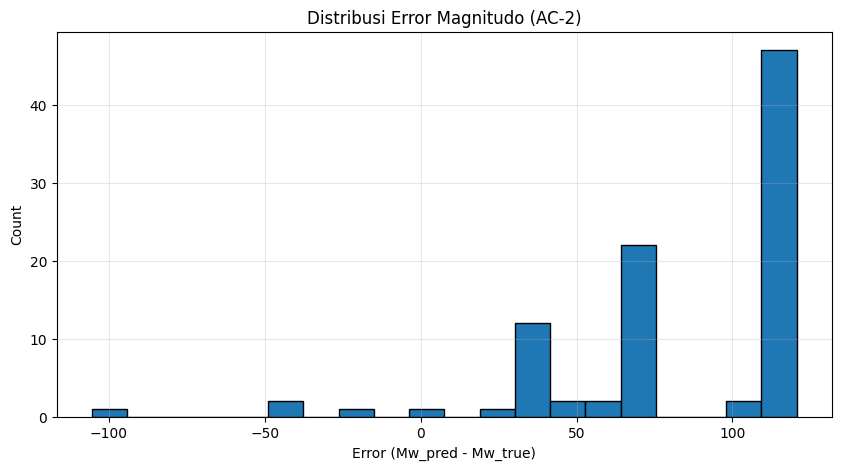

In [60]:
df = pd.read_csv("/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac2/ac2_results.csv")

df["error"] = df["Mw_pred"] - df["Mw_true"]

plt.figure(figsize=(10,5))
plt.hist(df["error"], bins=20, edgecolor='black')
plt.title("Distribusi Error Magnitudo (AC-2)")
plt.xlabel("Error (Mw_pred - Mw_true)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


In [61]:
df.sort_values("error", key=lambda x: abs(x)).head(10)


,station,Mw_pred,Mw_true,error
31,IWT0242602202316,4,6.4,-2.4
5,HKD1282602202316,-12,6.4,-18.4
83,AOM0272602202316,33,6.4,26.6
34,HKD0922602202316,43,6.4,36.6
88,IWT0022602202316,43,6.4,36.6
41,IWT0232602202316,43,6.4,36.6
87,HKD1102602202316,43,6.4,36.6
69,IWT0182602202316,43,6.4,36.6
9,HKD1582602202316,43,6.4,36.6
72,HKD0972602202316,43,6.4,36.6


In [63]:
import os

ac3_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac3"
os.makedirs(ac3_dir, exist_ok=True)


In [64]:
df_labels = df[["station", "Mw_pred"]].rename(columns={"Mw_pred": "Mw_teacher"})
df_labels.to_csv("/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac3/labels.csv", index=False)


In [65]:
os.listdir(ac3_dir)


['labels.csv']

In [66]:
import os
import shutil

ac1_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1"
ac3_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac3"

# pastikan subfolder waveforms ada
os.makedirs(f"{ac3_dir}/waveforms", exist_ok=True)

# daftar semua file .npy hasil AC-1
waveforms = [f for f in os.listdir(ac1_dir) if f.endswith(".npy")]

for fname in waveforms:
    src = f"{ac1_dir}/{fname}"
    dst = f"{ac3_dir}/waveforms/{fname}"
    shutil.copy(src, dst)

print("Semua waveform AC-1 berhasil disalin ke folder AC-3.")


Semua waveform AC-1 berhasil disalin ke folder AC-3.


In [67]:
import os
import pandas as pd

ac3_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac3"
df = pd.read_csv(f"{ac3_dir}/labels.csv")

missing = []
for station in df.station:
    if not os.path.exists(f"{ac3_dir}/waveforms/{station}.npy"):
        missing.append(station)

missing[:10], len(missing)


([], 0)

In [68]:
df.station.duplicated().sum()


np.int64(0)

In [88]:
# === ARSITEKTUR AC-2 BARU UNTUK MW BESAR ===
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ac2_bigMw():
    inputs = layers.Input(shape=(300, 3))

    # Blok 1
    x = layers.Conv1D(32, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Blok 2
    x = layers.Conv1D(64, 7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Blok 3
    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.15)(x)

    # Blok 4 (dalam, tapi tetap ringan)
    x = layers.Conv1D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # Output Mw langsung (tanpa aktivasi)
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs, name="AC2_BigMw")
    return model

model_ac2 = build_ac2_bigMw()
model_ac2.summary()


Model: "AC2_BigMw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 300, 32)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 300, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 300, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 150, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 75, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 37, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 197,889 (773.00 KB)

 Trainable params: 196,929 (769.25 KB)

 Non-trainable params: 960 (3.75 KB)

In [89]:
# === COMPILE AC-2 BARU ===
model_ac2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(),  # lebih stabil dari MSE
    metrics=['mae']
)


In [94]:
# === CARI FOLDER YANG BERISI FILE .npy WAVEFORM ===
import os

root = "/Volumes/Local Disk/Code_Git/S3_code/seismic"
for path, dirs, files in os.walk(root):
    for f in files:
        if f.endswith(".npy"):
            print(os.path.join(path, f))


/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1062602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1112602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1822602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/AOM0222602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD0782602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1282602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/AOM0082602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/AOM0262602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/IWT0072602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/HKD1582602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/IWT0142602202316.npy
/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac1/M

In [95]:
# === BUILD DATASET AC-2 BARU DARI FOLDER AC-3 ===
import os
import re
import pandas as pd

wave_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/processed_ac3/waveforms"
out_dir  = "/Volumes/Local Disk/Code_Git/S3_code/seismic/dataset_ac2"

os.makedirs(f"{out_dir}/waveforms", exist_ok=True)

Mw_event = 6.4  # magnitudo event ini

rows = []

pattern = re.compile(r"([A-Z]+[0-9]+)([0-9]+)\.npy")

for fname in os.listdir(wave_dir):
    if not fname.endswith(".npy"):
        continue

    match = pattern.match(fname)
    if not match:
        continue

    station = match.group(1)
    event_id = match.group(2)

    src = f"{wave_dir}/{fname}"
    dst = f"{out_dir}/waveforms/{fname}"

    if not os.path.exists(dst):
        os.system(f"cp '{src}' '{dst}'")

    rows.append({
        "event_id": event_id,
        "station": station,
        "Mw": Mw_event,
        "path": f"waveforms/{fname}"
    })

df = pd.DataFrame(rows)
df.to_csv(f"{out_dir}/metadata.csv", index=False)

print("Metadata saved:", f"{out_dir}/metadata.csv")
df.head()


Metadata saved: /Volumes/Local Disk/Code_Git/S3_code/seismic/dataset_ac2/metadata.csv


,event_id,station,Mw,path
0,6,HKD106260220231,6.4,waveforms/HKD1062602202316.npy
1,6,HKD111260220231,6.4,waveforms/HKD1112602202316.npy
2,6,HKD182260220231,6.4,waveforms/HKD1822602202316.npy
3,6,AOM022260220231,6.4,waveforms/AOM0222602202316.npy
4,6,HKD078260220231,6.4,waveforms/HKD0782602202316.npy


In [97]:
df = pd.read_csv("/Volumes/Local Disk/Code_Git/S3_code/seismic/dataset_ac2/metadata.csv")
df.head()
df.event_id.nunique(), df.station.nunique()


(1, 93)

In [8]:
# === DETEKSI SEMUA EVENT K-NET LOKAL ===
import os

root = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet"

event_dirs = []
for name in os.listdir(root):
    path = os.path.join(root, name)
    if os.path.isdir(path) and name.endswith(".knt"):
        event_dirs.append(path)

event_dirs


['/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt']

In [9]:
import os

event_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/knet/20260220231600.knt"
os.listdir(event_path)


['IWT0052602202316.wave.ps.gz',
 'HKD1852602202316.wave.ps.gz',
 'HKD1852602202316.EW',
 'AOM0212602202316.EW',
 'HKD1102602202316.rsp.ps.gz',
 'HKD1282602202316.EW',
 'HKD0942602202316.rsp.ps.gz',
 'HKD1822602202316.EW',
 'AOM0262602202316.EW',
 'AOM0212602202316.rsp.ps.gz',
 'IWT0232602202316.NS',
 'HKD1092602202316.rsp.ps.gz',
 'HKD1582602202316.rsp.ps.gz',
 'HKD1622602202316.NS',
 'IWT0242602202316.NS',
 'HKD1302602202316.NS',
 'AOM0242602202316.wave.ps.gz',
 '20260220231600.knt_rsc2000map.ps.gz',
 'HKD1112602202316.rsp.ps.gz',
 'AOM0202602202316.rsp.ps.gz',
 'HKD0952602202316.rsp.ps.gz',
 'HKD0662602202316.rsp.ps.gz',
 'HKD1252602202316.NS',
 'AOM0212602202316.wave.ps.gz',
 'AOM0222602202316.UD',
 'HKD0992602202316.wave.ps.gz',
 'HKD1322602202316.wave.ps.gz',
 'HKD1812602202316.UD',
 'HKD1082602202316.rsp.ps.gz',
 'HKD1592602202316.rsp.ps.gz',
 'AOM0022602202316.EW',
 'HKD1592602202316.EW',
 'HKD0962602202316.wave.ps.gz',
 'IWT0182602202316.EW',
 'AOM0052602202316.EW',
 'HKD095260